<a href="https://colab.research.google.com/github/Mohiddin25/Deep-Learning/blob/main/Perceptron_Trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Understanding the Working of a Perceptron

The following implementation explains the core intuition behind the Perceptron learning algorithm from scratch using the **Iris** dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

In [ ]:
from sklearn.datasets import load_iris
print(load_iris().keys())
df=load_iris().data


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [ ]:
load_iris().target[:100]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
load_iris().feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [ ]:
x=df[:100,:2]
y=load_iris().target[:100]
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

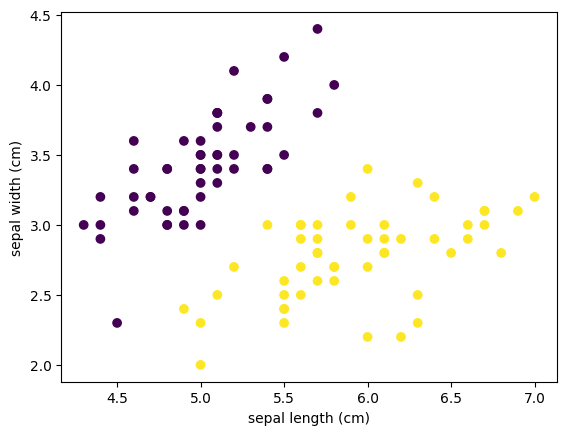

In [ ]:
#visualization of our dataset
plt.scatter(df[:100,0],df[:100,1],c=load_iris().target[:100])
plt.xlabel(load_iris().feature_names[0])
plt.ylabel(load_iris().feature_names[1])
plt.show()

In [ ]:
# A simple activation function
def activation(n):
  if n>0:
    return 1
  else:
    return 0


In [ ]:
# since change of weigths include bias and coeff, this step add a new column bias with all 1's
x_new = np.hstack((np.ones((x.shape[0], 1)), x))

In [ ]:
#Perceptron function
def perceptron(x,weights,alpha=0.1):
  for i in range(1000):
    random_point=np.random.randint(0,100) # selects a random row number
    y_pred=activation(np.dot(x[random_point],weights)) # with the help of above function predicting 'y'
    weights=weights+alpha*(y[random_point]-y_pred)*x[random_point] # Perceptron Weight Update Rule

  return weights

In [ ]:
w=perceptron(x_new,weights=[1,1,1],alpha=0.1) #initial weights [1,1,1]
w

array([ 0.2,  2.2, -3.9])

In [ ]:
X = np.linspace(2, 7, 100)
Y=-(w[1]/w[2])*X-(w[0]/w[2])

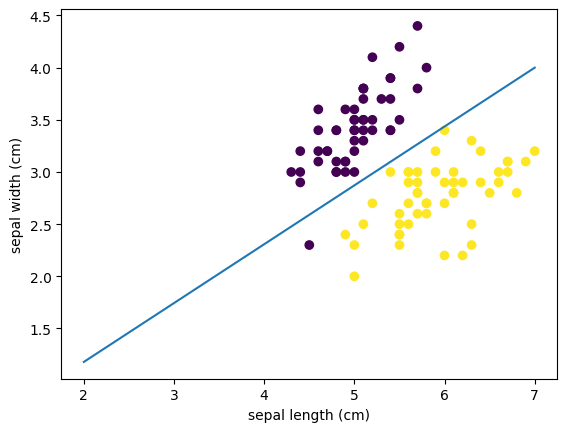

In [ ]:
#best fit line after the 1000 iteration that seperates 2 different classes
plt.scatter(df[:100,0],df[:100,1],c=load_iris().target[:100])
plt.plot(X,Y)
plt.xlabel(load_iris().feature_names[0])
plt.ylabel(load_iris().feature_names[1])
plt.show()